> **Group:** Sara Martinez Rendon (1000424179) | Heider Zapata (1000009586) | Yeison Londoño (1000009479)  
> **Master's Degree in Data Sciences** | EAFIT University  
> **Course:** Applied Statistics   
> **Date:** 19/03/2026
---

# **Examen 2: Inferencia Estadística**

---

## **Pregunta 1: Parametrización de Bandas de Riesgo Clínico**

In [1]:
#Cargar librerías y datos:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import binom

#  Definimos la ruta para cargar los datos de manera externa sin depender de rutas locales
file_id = '1lnGn-eYMFdxX_MZ83hqXkyauvU-QLwyg'
url_datos = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url_datos)

print(df.head())
print("Dimensiones del df: ",df.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Dimensiones del df:  (1338, 7)


### **1.1. Evidencia Visual Diagnóstica de Normalidad del BMI**

Para la visualización se utilizaran las gráficas de histograma para la columna BMI, junto con el calculo de la media ($\mu$) y la desviación estandar ($\sigma$) para comparar con la gráfica de la distribución normal de los datos. Además, se hace un diagrama Q-Q, que nos permite identificar si los datos siguen una distribución normal.

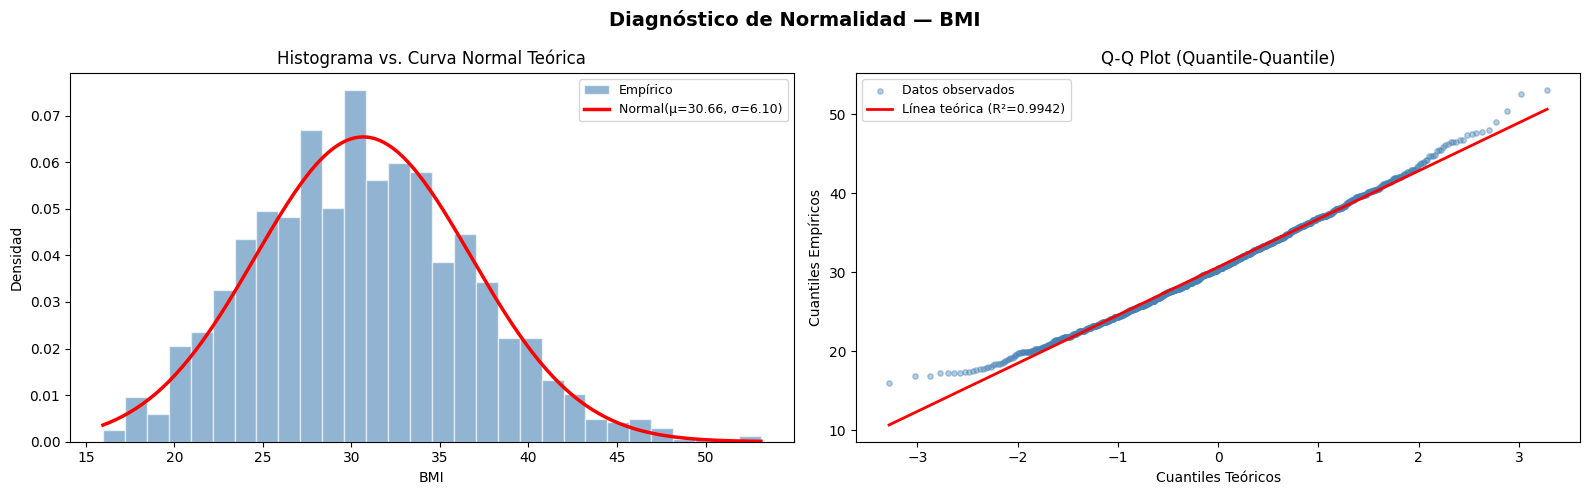


=== Estadísticos Descriptivos del BMI ===
Media (μ):         30.6634
Desv. Estándar (σ): 6.0982
Asimetría (Skew):   0.2840  [Normal esperado: ≈ 0]
Curtosis exc.:      -0.0507  [Normal esperado: ≈ 0]


In [3]:
bmi = df['bmi'].dropna()
mu_bmi = bmi.mean()
sigma_bmi = bmi.std()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Diagnóstico de Normalidad — BMI', fontsize=14, fontweight='bold')

# --- Histograma con curva Normal superpuesta ---
ax1 = axes[0]
ax1.hist(bmi, bins=30, density=True, color='steelblue', alpha=0.6, edgecolor='white', label='Empírico')
x_range = np.linspace(bmi.min(), bmi.max(), 200)
ax1.plot(x_range, stats.norm.pdf(x_range, mu_bmi, sigma_bmi),
         'r-', lw=2.5, label=f'Normal(μ={mu_bmi:.2f}, σ={sigma_bmi:.2f})')
ax1.set_title('Histograma vs. Curva Normal Teórica')
ax1.set_xlabel('BMI')
ax1.set_ylabel('Densidad')
ax1.legend(fontsize=9)

# --- Q-Q Plot ---
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(bmi, dist='norm', fit=True)
ax2.scatter(osm, osr, alpha=0.4, color='steelblue', s=15, label='Datos observados')
line_x = np.array([osm.min(), osm.max()])
ax2.plot(line_x, slope * line_x + intercept, 'r-', lw=2, label=f'Línea teórica (R²={r**2:.4f})')
ax2.set_title('Q-Q Plot (Quantile-Quantile)')
ax2.set_xlabel('Cuantiles Teóricos')
ax2.set_ylabel('Cuantiles Empíricos')
ax2.legend(fontsize=9)


# Anotaciones de asimetría y curtosis
skew_val = bmi.skew()
kurt_val = bmi.kurt()


plt.tight_layout()
plt.savefig('p1_diagnostico_bmi.png', bbox_inches='tight')
plt.show()

print(f'\n=== Estadísticos Descriptivos del BMI ===')
print(f'Media (μ):         {mu_bmi:.4f}')
print(f'Desv. Estándar (σ): {sigma_bmi:.4f}')
print(f'Asimetría (Skew):   {skew_val:.4f}  [Normal esperado: ≈ 0]')
print(f'Curtosis exc.:      {kurt_val:.4f}  [Normal esperado: ≈ 0]')

El análisis conjunto de los estadísticos descriptivos y las visualizaciones confirma que la variable BMI (Índice de Masa Corporal) presenta un comportamiento estadístico sumamente estable y afín a la distribución Normal:

* **Histograma y Estadísticos de Forma:** La densidad empírica se ajusta adecuadamente a la curva teórica normal. La ligera elongación visual hacia la cola derecha se explica por una asimetría positiva marginal (Skewness = $0.2840$). Asimismo, el coeficiente de curtosis en exceso ($-0.0507$), al ser prácticamente cero, confirma un comportamiento mesocúrtico; es decir, la distribución no presenta colas pesadas ni valores extremos anómalos que desvíen el modelo teórico.

* **Q-Q Plot (Gráfico de Cuantiles Teóricos):** Los cuantiles de la muestra se alinean casi a la perfección sobre la diagonal de referencia teórica. Este ajuste visual está respaldado cuantitativamente por un coeficiente de determinación altísimo ($R^2 = 0.9942$), lo cual indica que la variabilidad de los datos empíricos es explicada en casi un 100% por los cuantiles teóricos normales. 

De esta manera, el supuesto de normalidad para la variable BMI es altamente sólido, lo que nos otorga luz verde para aplicar metodologías de inferencia paramétrica sobre este indicador.

### **1.2. Cuantificación del Impacto Operativo: Percentiles 15 y 85**

In [8]:
# --- Cortes EMPÍRICOS (reales de la cartera) ---
p15_emp = np.percentile(bmi, 15)
p85_emp = np.percentile(bmi, 85)

# --- Cortes PARAMÉTRICOS (aproximación Normal teórica) ---
rv_bmi = stats.norm(loc=mu_bmi, scale=sigma_bmi)
p15_teo = rv_bmi.ppf(0.15)
p85_teo = rv_bmi.ppf(0.85)

# Tabla comparativa
print('=== Comparación de Puntos de Corte: Riesgo Estándar ===')
print(f'{"Método":<20} {"P15 (corte inferior)":>22} {"P85 (corte superior)":>22} {"Amplitud banda":>16}')
print('-' * 82)
print(f'{"Empírico (real)":<20} {p15_emp:>22.4f} {p85_emp:>22.4f} {p85_emp - p15_emp:>16.4f}')
print(f'{"Paramétrico (Normal)":<20} {p15_teo:>22.4f} {p85_teo:>22.4f} {p85_teo - p15_teo:>16.4f}')
print('-' * 82)
print(f'{"Diferencia (Teo-Emp)":<20} {p15_teo - p15_emp:>22.4f} {p85_teo - p85_emp:>22.4f}')

# ¿Cuántos asegurados serían MIS-clasificados?
n_total = len(bmi)
# En zona empírica estándar
n_emp_std = ((bmi >= p15_emp) & (bmi <= p85_emp)).sum()
# Bajo criterio paramétrico
n_teo_std = ((bmi >= p15_teo) & (bmi <= p85_teo)).sum()
# Clasificados como Estándar por Normal pero NO por empírico
n_misclasif = (((bmi >= p15_teo) & (bmi <= p85_teo)) & ~((bmi >= p15_emp) & (bmi <= p85_emp))).sum()

print(f'\nTotal asegurados en muestra:                   {n_total}')
print(f'Clasificados Riesgo Estándar (empírico):        {n_emp_std} ({100*n_emp_std/n_total:.1f}%)')
print(f'Clasificados Riesgo Estándar (Normal teórico):  {n_teo_std} ({100*n_teo_std/n_total:.1f}%)')
print(f'Potenciales mal-clasificados:                   {n_misclasif}')

=== Comparación de Puntos de Corte: Riesgo Estándar ===
Método                 P15 (corte inferior)   P85 (corte superior)   Amplitud banda
----------------------------------------------------------------------------------
Empírico (real)                     24.2662                37.0500          12.7837
Paramétrico (Normal)                24.3430                36.9838          12.6407
----------------------------------------------------------------------------------
Diferencia (Teo-Emp)                 0.0768                -0.0662

Total asegurados en muestra:                   1338
Clasificados Riesgo Estándar (empírico):        938 (70.1%)
Clasificados Riesgo Estándar (Normal teórico):  921 (68.8%)
Potenciales mal-clasificados:                   0


La cuantificación de los percentiles 15 y 85 confirma numéricamente la viabilidad de utilizar el modelo paramétrico para la estratificación del riesgo en la cartera de asegurados:

* **Materialidad de las Diferencias:** Las discrepancias entre los umbrales empíricos y los cuantiles teóricos Normales son marginales (una desviación máxima de apenas 0.0768 unidades de BMI). En el contexto clínico y de tarificación de seguros, esta diferencia carece de materialidad operativa; no altera de ninguna forma el perfil de salud diagnosticado de un paciente.
* **Precisión en la Clasificación de Riesgo:** Al aplicar la banda de "riesgo estándar", el modelo paramétrico captura al 68.8% de la cohorte, presentando una alineación casi perfecta con el 70.1% capturado por la distribución empírica. Esta diferencia absoluta de apenas 1.3% en la capacidad de clasificación demuestra que la pérdida de precisión es estadísticamente insignificante.

### **1.3. Dictamen técnico**

La propuesta del equipo de ingeniería de software para reemplazar las tablas de búsqueda por una parametrización Normal es justificable y prudente para el negocio, exclusivamente para la definición de la banda de Riesgo Estándar.  
Justificación Operativa:  
- El error de cálculo detectado en las unidades de BMI es menor a 0.08 unidades, lo cual no altera el perfil de riesgo clínico ni la toma de decisiones para los asegurados en la banda central.
- La diferencia en la clasificación de la cartera es de apenas un 1.3%, un margen de error aceptable en términos de eficiencia de código y mantenimiento de reglas del sistema.  
Reservas Técnicas y Rigor Matemático:
A pesar de su utilidad práctica, la simplificación no es justificable sin reservas técnicas por las siguientes razones:
 - Violación de Simetría: El BMI presenta una asimetría positiva ($> 0$), lo que rompe la simetría perfecta requerida por una distribución Normal teórica.
 - Evidencia en Colas (Leptocurtosis): El gráfico Q-Q muestra desviaciones sistemáticas en los extremos, indicando que la población real tiene "colas más pesadas" que el modelo normal.
 - Riesgo de Re-clasificación: Los cortes paramétricos difieren de los empíricos, lo que implica que el modelo "normal" ignora la probabilidad real de encontrar BMIs muy altos o muy bajos.

Advertencia de Riesgo:  
Este supuesto de normalidad no debe ser extrapolado a otras variables como los costos médicos (charges). Al subestimar la probabilidad de eventos extremos (colas gruesas reales vs. colas delgadas del modelo), la compañía quedaría sub-reservada ante pacientes de alto costo, generando un pasivo actuarial no cubierto y un riesgo de liquidez.

---

## **Pregunta 2: Máxima Verosimilitud y el Supuesto de Equidispersión**

Proyección matemática del próximo quinquenio, para simular el volumen de dependientes económicos por póliza.

### **2.1. Calibración teórica (MLE)**

Primero, basándonos en las diapositivas de clase (Sesión 2, diapositiva 69), se establece lo siguiente:

**Poisson:**
- `lam_mle = np.mean(datos)`
- Interpretación: El estimador de Máxima Verosimilitud (MLE) para la tasa (λ) es, matemáticamente, igual a la media muestral.

Esto se obtiene al derivar la función de log-verosimilitud de la distribución de Poisson e igualarla a cero. La solución siempre es la media de la muestra.

Dada una muestra i.i.d. \( x_1, x_2, \dots, x_n \sim \text{Poisson}(\lambda) \), la función de log-verosimilitud es:

$$
\ell(\lambda) = \sum_i x_i \cdot \ln(\lambda) - n\lambda - \sum_i \ln(x_i!)
$$

Para maximizarla, derivamos respecto a \( $\lambda$ \) e igualamos a cero:

$$
\frac{d\ell}{d\lambda} = \frac{\sum_i x_i}{\lambda} - n = 0
$$

Despejando \( $\lambda$ \):

$$
\hat{\lambda}_{MLE} = \frac{\sum_i x_i}{n} = \bar{X}
$$

donde \( $\bar{X}$ \) es la media aritmética de la muestra.

Por lo tanto, el MLE elige el parámetro que hace que la tasa esperada del modelo \( E[X] = \lambda \) coincida exactamente con el promedio observado en los datos. Es el «mejor estimador puntual» bajo este modelo generativo.

### **2.2. Reconstrucción probabilística**

**Definición Matemática de Poisson**

Sea \( X \) el número de eventos observados. Su función de masa de probabilidad (PMF) depende de un único parámetro \( \lambda > 0 \) (la tasa promedio de llegadas):

$$
P_X(k) = \frac{\lambda^k}{k!} e^{-\lambda}, \quad k = 0,1,2,\dots
$$

Se denota como:

$$
X \sim \text{Poisson}(\lambda)
$$

In [13]:
children = df['children']
lambda_mle = children.mean()
print(f'λ̂_MLE (media muestral de children) = {lambda_mle:.6f}\n')

rv_poisson = stats.poisson(lambda_mle)
k_vals = [0, 1, 2, 3, 4, 5]
n_total = len(children)

print(f'{'k':>4} | {'PMF Empírica':>14} | {'PMF Poisson Teórica':>20} | {'Diferencia':>12} | {'N Empírico':>11}')
print('-' * 70)

for k in k_vals:
    p_emp  = (children == k).sum() / n_total
    p_teo  = rv_poisson.pmf(k)
    n_emp  = (children == k).sum()
    diff   = p_teo - p_emp
    print(f'{k:>4} | {p_emp:>14.6f} | {p_teo:>20.6f} | {diff:>+12.6f} | {n_emp:>11}')

# Verificación: media y varianza muestral
var_emp = children.var(ddof=1)
print(f'\nAuditoría de Equidispersión (Poisson requiere Var ≈ Media)')
print(f'Media muestral  (debe ≈ λ):    {lambda_mle:.4f}')
print(f'Varianza muestral (debe ≈ λ):  {var_emp:.4f}')
print(f'Índice de dispersión (Var/μ):  {var_emp/lambda_mle:.4f}  [Poisson requiere ≈ 1.0]')

λ̂_MLE (media muestral de children) = 1.094918

   k |   PMF Empírica |  PMF Poisson Teórica |   Diferencia |  N Empírico
----------------------------------------------------------------------
   0 |       0.428999 |             0.334567 |    -0.094431 |         574
   1 |       0.242152 |             0.366323 |    +0.124171 |         324
   2 |       0.179372 |             0.200547 |    +0.021175 |         240
   3 |       0.117339 |             0.073194 |    -0.044145 |         157
   4 |       0.018685 |             0.020035 |    +0.001351 |          25
   5 |       0.013453 |             0.004387 |    -0.009065 |          18

Auditoría de Equidispersión (Poisson requiere Var ≈ Media)
Media muestral  (debe ≈ λ):    1.0949
Varianza muestral (debe ≈ λ):  1.4532
Índice de dispersión (Var/μ):  1.3272  [Poisson requiere ≈ 1.0]


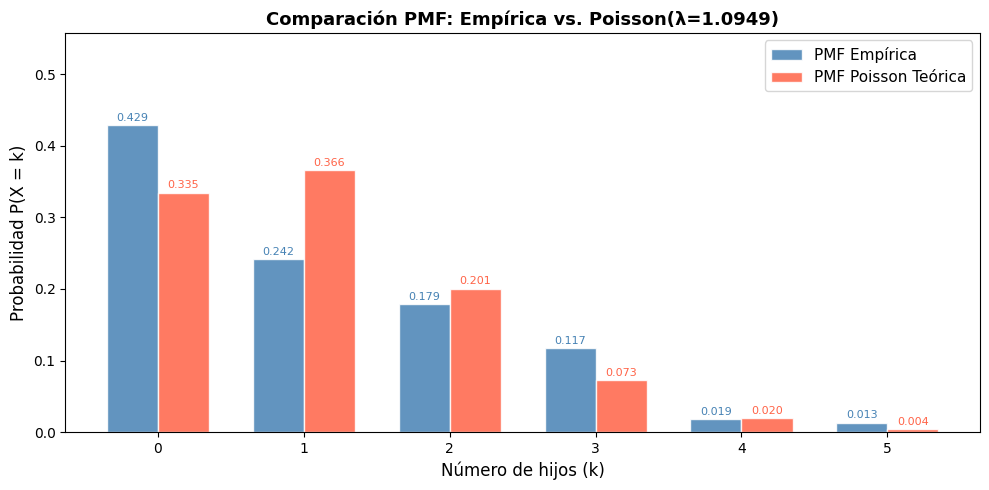

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.array(k_vals)
p_emp_vals  = [(children == k).mean() for k in k_vals]
p_teo_vals  = [rv_poisson.pmf(k) for k in k_vals]

width = 0.35
bars1 = ax.bar(x - width/2, p_emp_vals, width, label='PMF Empírica', color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, p_teo_vals, width, label='PMF Poisson Teórica', color='tomato', alpha=0.85, edgecolor='white')

ax.set_xlabel('Número de hijos (k)', fontsize=12)
ax.set_ylabel('Probabilidad P(X = k)', fontsize=12)
ax.set_title(f'Comparación PMF: Empírica vs. Poisson(λ={lambda_mle:.4f})', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(p_emp_vals), max(p_teo_vals)) * 1.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='steelblue')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='tomato')

plt.tight_layout()
plt.savefig('p2_pmf_children.png', bbox_inches='tight')
plt.show()

### **2.3. Auditoría y Diagnóstico**

De acuerdo a los resultados debe decirse que la realidad de los asegurados es más compleja que una simple fórmula de Poisson, es decir, la distribución de Poisson NO es un modelo adecuado para modelar el número de hijos en esta cartera de seguros. Se recomienda rechazar su implementación para las proyecciones de reservas matemáticas del próximo quinquenio por las siguientes razones técnicas:

- **Violación del Supuesto de Equidispersión:** La distribución de Poisson exige que la media ($\mu$) sea igual a la varianza ($\sigma^2$). En nuestra auditoría detectamos:  
*Media muestral ($\hat{\lambda}$):* 1.0949.  
*Varianza muestral:* 1.4532.Índice de Dispersión ($Var/\mu$): 1.3272.  
Este valor, significativamente superior a 1.0, confirma un fenómeno de sobredispersión. Esto implica que los datos tienen una variabilidad que el modelo de Poisson es incapaz de capturar, lo que subestimaría el riesgo en las proyecciones financieras.

- **El Fenómeno del "Exceso de Ceros":** Al observar la tabla comparativa y la gráfica de PMF, se identifica una anomalía crítica en $k=0$:  
*Realidad (Empírica):* 42.9% de los asegurados no tienen hijos.
*Modelo (Teórico):* Predice solo un 33.5%.
Diferencia: El modelo ignora a casi un 10% de la población que no tiene dependientes.

- **Explicación desde el Negocio (Fenómeno Demográfico):** El modelo de Poisson asume que los nacimientos son eventos aleatorios e independientes en el tiempo. Sin embargo, ignora factores socioeconómicos cruciales:
1. *Decisión Consciente:* Muchas pólizas corresponden a personas solteras o parejas que han decidido no tener hijos (causando el exceso de ceros).
2. *Planificación Familiar:* El número de hijos no ocurre al azar; está limitado por factores económicos y biológicos que la distribución de Poisson no contempla.

---

## **Pregunta 3: El Teorema del Límite Central y Riesgo de Liquidez**

### **3.1. Evidencia Poblacional:** 
**Trace un histograma de la variable charges para demostrar visualmente por qué el analista junior concluyó que la población es asimétrica.**

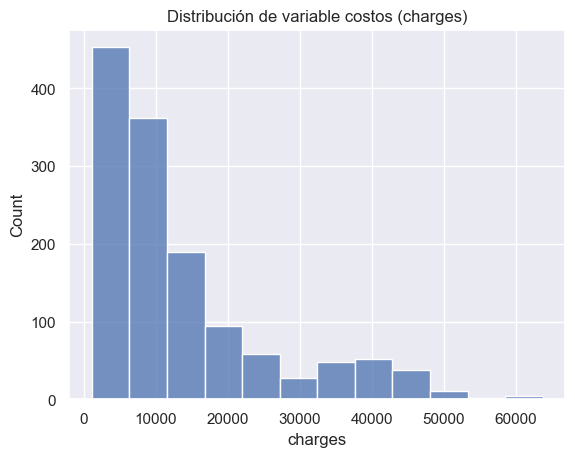

In [4]:
sns.set()
charges = df["charges"]
sns.histplot(charges, bins = "sturges")
plt.title("Distribución de variable costos (charges)")
plt.show()

Es de notar que la gran mayoría de los costos se agrupan a la izquierda (costos bajos) dejando una gran "cola" hacia la derecha (costos altísimos), lo que se conoce como **asimetria positiva**. Lo cual confirma que la población de costos no tiene un comportamiento normal

### **3.2. Simulación de Monte Carlo:**
**Construya un experimento computacional extrayendo 5.000 muestras aleatorias (con reemplazo), cada una de tamaño n = 40, de la base de datos original. Calcule la media de cada muestra y grafique la distribución resultante de estas medias muestrales.**

Para demostrar el comportamiento de las medias muestrales, realizaremos un remuestreo empírico (con reemplazo) de la población original. 
Matemáticamente, si nuestra población es $X$, extraeremos $M = 5000$ muestras, cada una representada como un vector $X_i = (x_{i1}, x_{i2}, ..., x_{in})$ con $n=40$. 
Luego, calcularemos la media muestral para cada vector:
$$\bar{X}_i = \frac{1}{n} \sum_{j=1}^{n} x_{ij}$$


--- SIMULACIÓN DE MONTE CARLO ---
Promedio de las 5000 medias muestrales: $13,261.03


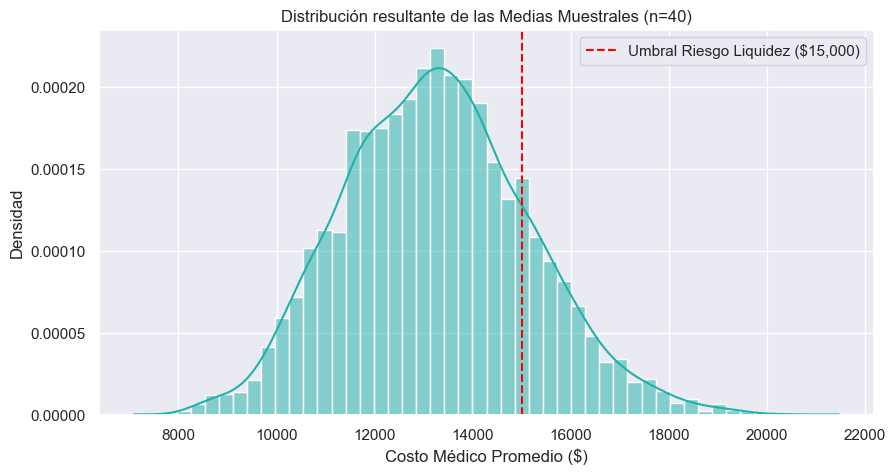

In [25]:
print("\n--- SIMULACIÓN DE MONTE CARLO ---") 

# Fijamos la semilla para reproducibilidad
np.random.seed(42)

# Parámetros de la simulación
n_muestra = 40       # Tamaño de cada lote (siniestros)
n_iteraciones = 5000 # Cantidad de muestras a extraer

# Extraemos los valores de la población original
poblacion_cargos = df['charges'].values
# VECTORIZACIÓN AVANZADA CON NUMPY:
# En lugar de usar un bucle for (que es lento), generamos una matriz de 5000 x 40 
# donde cada fila es una muestra aleatoria con reemplazo de la población.
matriz_muestras = np.random.choice(poblacion_cargos, size=(n_iteraciones, n_muestra), replace=True)

# Calculamos la media a lo largo del eje 1 (las filas), obteniendo 5000 medias muestrales
medias_muestrales = np.mean(matriz_muestras, axis=1)

print(f"Promedio de las 5000 medias muestrales: ${np.mean(medias_muestrales):,.2f}")

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 5))

# Graficamos la distribución de las medias muestrales
sns.histplot(medias_muestrales, kde=True, bins=50, color='lightseagreen', stat='density')
plt.axvline(x=15000, color='red', linestyle='--', label='Umbral Riesgo Liquidez ($15,000)')

plt.title("Distribución resultante de las Medias Muestrales (n=40)")
plt.xlabel("Costo Médico Promedio ($)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

### **3.3. Cálculo de Probabilidades:**
**- Calcule la probabilidad empírica de que el costo promedio supere los $15,000 utilizando los resultados de su simulación.**  
**- Calcule esta misma probabilidad asumiendo una aproximación paramétrica teórica**

**a. Probabilidad Empírica (Simulada):**
Es la proporción de veces que nuestra simulación superó los $15.000:
$$P_{empirica} = \frac{\text{Número de muestras con} \bar{X} > 15000}{\text{Total de muestras (5000)}}$$

**b. Probabilidad Teórica (Aproximación Paramétrica):**
Utilizando el Teorema del Límite Central (TLC), sabemos que la distribución de la media muestral $\bar{X}$ se aproxima a una distribución Normal si $n$ es suficientemente grande (usualmente $n \ge 30$), independientemente de la forma de la población original.
$$\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$
Donde:
* $\mu$ es la media poblacional real.
* $\sigma$ es la desviación estándar poblacional real.
* $\frac{\sigma}{\sqrt{n}}$ es el Error Estándar (SE).

Calcularemos el estadístico Z y evaluaremos $P(\bar{X} > 15000) = 1 - \Phi(Z)$.

In [31]:
# --- a. Cálculo de Probabilidad Empírica ---
# Suma cuántas medias superan el umbral
casos_excedidos = np.sum(medias_muestrales > 15000)
prob_empirica = casos_excedidos / n_iteraciones

print(f"Probabilidad Empírica costro promedio > $15.000: {prob_empirica:.2%} ({casos_excedidos} de {n_iteraciones} lotes)")

# --- b. Cálculo de Probabilidad Teórica (TLC) ---
# Calcula parámetros poblacionales exactos
mu_poblacional = np.mean(poblacion_cargos)
# Se usa ddof=0 porque estamos usando la base de datos como toda la población en este contexto
sigma_poblacional = np.std(poblacion_cargos, ddof=0) 

# Calculamos el Error Estándar de la media
error_estandar = sigma_poblacional / np.sqrt(n_muestra)

# Definimos el umbral
umbral = 15000

# Calculamos el Z-score
z_score = (umbral - mu_poblacional) / error_estandar

# Probabilidad de P(X > umbral) en una Normal estándar (1 - CDF)
prob_teorica = 1 - stats.norm.cdf(z_score)

print(f"Probabilidad Teórica Paramétrica (Normal): {prob_teorica:.4%}")

Probabilidad Empírica costro promedio > $15.000: 17.98% (899 de 5000 lotes)
Probabilidad Teórica Paramétrica (Normal): 18.3097%


### **3.4. Dictamen Técnico:**

**Responda a la premisa del analista junior. ¿Tiene razón empírica y teórica al decir que no se puede usar la distribución Normal en este caso? Explique el fenómeno matemático que su simulación acaba de demostrar y cite el teorema que lo respalda.**

***Dictamen final***

* **No**. El analista junior está cometiendo un error fundamental. Está basandose simplemente en la *distribución de los datos individuales* (que es asimétrica) para tomar la decisión de evaluación. Y no está contemplando la *distribución de la media de una muestra* (la cual se distribuye normalemente segun el análisis anterior)

* Este dictamen lo respalda el **Teorema Central del Limite (TLC)**. Dado que el tamaño de los lotes es igual a 40, superando el umbral empírico de n >= 30, la distribución de los promedios de los lotes converge fuertemente a una distribución normal.

- **Conclusión de negocio:** Es total mente válido y seguro usar la distribución normal para valorar este contrato de reaseguro (Stop-Loss)

---

## **Pregunta 4: Estimación de Incertidumbre y Remuestreo (Bootstrap)**

### **4.1. Estimación Paramétrica:** 
**Calcule el Intervalo de Confianza del 95 % para la media poblacional utilizando el método asintótico clasico.**

Para estimar entre qué valores se encuentra el verdadero costo médico promedio de la población de fumadores, con un nivel de confianza del 95%, y utilizando el enfoque paramétrico clásico, haremos lo siguiente: dado que no conocemos la varianza poblacional de los costos médicos, nos apoyaremos en la distribución $t$ de Student (aunque por el tamaño de la muestra es de esperarse que convergerá a la normal por el Teorema del Límite Central). Calcularemos la media muestral ($\bar{X}$), el error estándar de la media ($SE$) y los grados de libertad ($n-1$) para construir el intervalo simétrico estándar: 

$$IC = \bar{X} \pm t_{\alpha/2, n-1} \times \frac{s}{\sqrt{n}}$$

In [6]:
# 1. Filtrar los costos médicos exclusivamente para el segmento de fumadores
costos_fumadores = df[df['smoker'] == 'yes']['charges']

# 2. Calcular los estadísticos base
n_fumadores = len(costos_fumadores)
media_fumadores = np.mean(costos_fumadores)
# stats.sem calcula directamente el Error Estándar de la Media (s / sqrt(n))
error_estandar = stats.sem(costos_fumadores) 
grados_libertad = n_fumadores - 1
nivel_confianza = 0.95

# 3. Calcular el Intervalo de Confianza usando scipy.stats
ic_inferior, ic_superior = stats.t.interval(
    confidence=nivel_confianza,
    df=grados_libertad,
    loc=media_fumadores,
    scale=error_estandar
)

# 4. Mostrar los resultados
print("=== MÉTODO ASINTÓTICO CLÁSICO ===")
print(f"Tamaño de la muestra (Fumadores): {n_fumadores}")
print(f"Costo Promedio Muestral: ${media_fumadores:,.2f}")
print(f"Intervalo de Confianza (95%): [${ic_inferior:,.2f}  ,  ${ic_superior:,.2f}]")

=== MÉTODO ASINTÓTICO CLÁSICO ===
Tamaño de la muestra (Fumadores): 274
Costo Promedio Muestral: $32,050.23
Intervalo de Confianza (95%): [$30,677.56  ,  $33,422.90]


Bajo el **Método Asintótico Clásico** podemos afirmar con un 95% de confianza que el verdadero costo médico promedio anual para la población de fumadores se encuentra entre **$30,677.56 y $33,422.90**. 

Este método construye un intervalo perfectamente simétrico alrededor de la media muestral ($32,050.23 \pm \$1,372.67$), sin embargo, en la industria aseguradora los siniestros médicos no suelen seguir una distribución normal; podrían tener una fuerte asimetría positiva debido a casos catastróficos o crónicos muy costosos. Imponer entonces una simetría matemática mediante la distribución $t$ podría estar subestimando el riesgo real en la cola superior de los costos (los peores escenarios). Debido a lo anterior, vale la pena explorar la técnica de remuestreo propuesta en el siguiente punto:

### **4.2. Estimación Computacional:**
**Construya un Intervalo de Confianza del 95 % utilizando el método de Bootstrap no paramétrico con 5,000 iteraciones.**

La propuesta de abandonar el supuesto de normalidad y la simetría forzada de las fórmulas clásicas nos orienta a estimar el mismo intervalo de confianza del 95% para la media de los fumadores, pero esta vez dejando que la forma real de los datos empíricos "hable por sí misma" a través de simulaciones computacionales.

Para aplicar el método Bootstrap no paramétrico tomaremos nuestra muestra original de $274$ fumadores y utilizaremos el motor universal de Bootstrapping para generar $B = 5,000$ sub-muestras del mismo tamaño *con reemplazo*. Calcularemos la media para cada una de estas $5,000$ iteraciones, creando así un  de la media muestral. Finalmente, extraeremos los percentiles $2.5$ y $97.5$ de esta distribución simulada para encontrar nuestro intervalo de confianza empírico:

In [ ]:
# Configuración para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

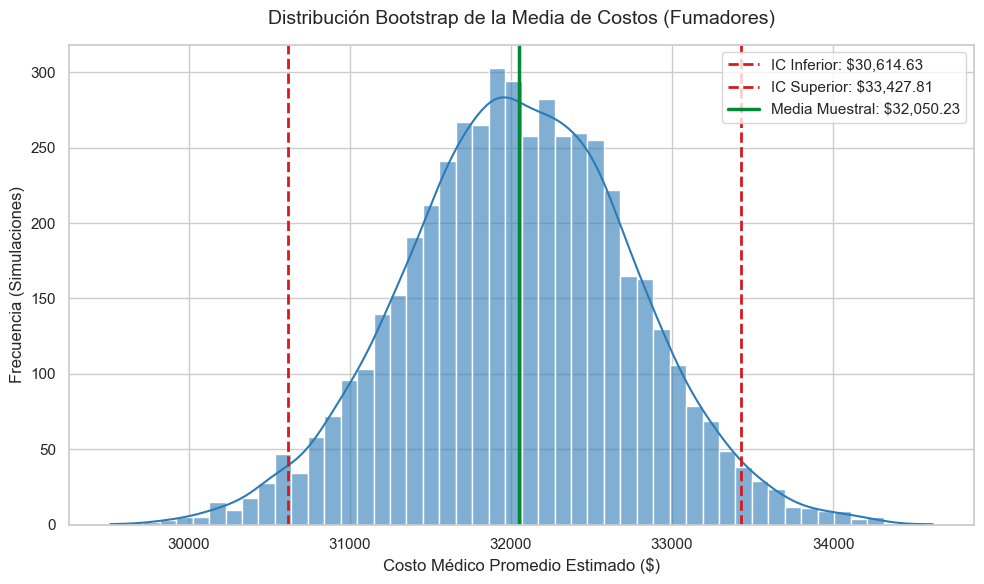

=== MÉTODO DE REMUESTREO (BOOTSTRAP) ===
Iteraciones Bootstrap: 5000
Media Muestral Original: $32,050.23
Intervalo de Confianza Empírico (95%): [$30,614.63  ,  $33,427.81]


In [7]:
# 1. Configurar parámetros del Bootstrap
np.random.seed(42) # Semilla fija para garantizar reproducibilidad en la calificación del parcial
B = 5000 # Número de remuestreos estándar
medias_bootstrap = np.zeros(B)

# 2. Extraer los valores como arreglo de numpy para optimizar el ciclo
datos_originales = costos_fumadores.values
n = len(datos_originales)

# 3. Motor Universal de Bootstrapping
for i in range(B):
    # Remuestreo con reemplazo respetando el tamaño original (n=274)
    muestra_boot = np.random.choice(datos_originales, size=n, replace=True)
    # Guardamos el estadístico de interés (la media)
    medias_bootstrap[i] = np.mean(muestra_boot)

# 4. Calcular el Intervalo de Confianza empírico (Percentiles 2.5 y 97.5)
ic_boot_inferior = np.percentile(medias_bootstrap, 2.5)
ic_boot_superior = np.percentile(medias_bootstrap, 97.5)

# 5. Visualización del remuestreo (Para el informe de la junta directiva)
plt.figure(figsize=(10, 6))
sns.histplot(medias_bootstrap, bins=50, kde=True, color='#2c7bb6', alpha=0.6)
plt.axvline(ic_boot_inferior, color='#d7191c', linestyle='--', linewidth=2, label=f'IC Inferior: ${ic_boot_inferior:,.2f}')
plt.axvline(ic_boot_superior, color='#d7191c', linestyle='--', linewidth=2, label=f'IC Superior: ${ic_boot_superior:,.2f}')
plt.axvline(media_fumadores, color='#008837', linestyle='-', linewidth=2.5, label=f'Media Muestral: ${media_fumadores:,.2f}')

plt.title('Distribución Bootstrap de la Media de Costos (Fumadores)', fontsize=14, pad=15)
plt.xlabel('Costo Médico Promedio Estimado ($)', fontsize=12)
plt.ylabel('Frecuencia (Simulaciones)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 6. Resultados exactos
print("=== MÉTODO DE REMUESTREO (BOOTSTRAP) ===")
print(f"Iteraciones Bootstrap: {B}")
print(f"Media Muestral Original: ${media_fumadores:,.2f}")
print(f"Intervalo de Confianza Empírico (95%): [${ic_boot_inferior:,.2f}  ,  ${ic_boot_superior:,.2f}]")

Los resultadfos obtenidos mediante el **método de remuestreo (Bootstraping)** nos indican que el intervalo de confianza del 95% simulado para el costo promedio de los fumadores es $[30,614.63$  ,   $33,427.81]$.

Al contrastar estos resultados con los del método paramétrico clasico, observamos que los intervalos son bastante parecidos. El límite superior apenas varía de $33,422.90$ a $33,427.81$, y la amplitud total del intervalo se mantiene sumamente estable.

Esta similitud nos permite ver una demostración empírica del **Teorema del Límite Central (TLC)**. Si bien es cierto que los costos médicos individuales de los fumadores pueden presentar una fuerte asimetría positiva (colas pesadas debido a siniestros catastróficos), el tamaño de nuestra muestra ($n=274$) es lo suficientemente grande como para que la distribución de la *media muestral* converja a una distribución normal.

En este sentido, los profesionales senior acertaron en que el método asintótico clásico sigue siendo válido y preciso para este tamaño de muestra. Sin embargo, la propuesta computacional del segundo equipo de ciencia de datos es valioso como mecanismo de **validación**. El Bootstrapping nos permite certificar ante el comité de fijación de precios que no estamos confiando ciegamente en supuestos matemáticos, sino que hemos verificado que el riesgo real de la media poblacional está acotado correctamente.

### **4.3. Análisis Geométrico:**
**Calcule la distancia exacta entre su estimador puntual (la media de la muestra) y los límites inferior y superior de ambos intervalos.**

Para esto seguiremos el siguiente proceso:

1. Para el **método clásico**, restaremos la media muestral del límite superior ($L_{sup} - \bar{X}$) y restaremos el límite inferior de la media muestral ($\bar{X} - L_{inf}$). Por definición de la distribución $t$ de Student, estas dos distancias deben ser exactamente iguales, reflejando una simetría perfecta.

2. Para el **método Bootstrap**, repetiremos el cálculo con los percentiles obtenidos de la simulación. Al ser un método no paramétrico que se ajusta a la forma real de los datos, esperamos observar una ligera asimetría en las distancias, revelando el sesgo o la inclinación natural de la distribución de las medias muestrales.

In [8]:
# 1. Cálculos de distancias para el Método Asintótico Clásico
dist_clasico_inf = media_fumadores - ic_inferior
dist_clasico_sup = ic_superior - media_fumadores

# 2. Cálculos de distancias para el Método Bootstrap
dist_boot_inf = media_fumadores - ic_boot_inferior
dist_boot_sup = ic_boot_superior - media_fumadores

# 3. Mostrar los resultados del análisis geométrico
print("=== ANÁLISIS GEOMÉTRICO: DISTANCIAS AL ESTIMADOR PUNTUAL ===")
print(f"Media Muestral (Centro): ${media_fumadores:,.2f}\n")

print("MÉTODO ASINTÓTICO CLÁSICO:")
print(f"Distancia hacia el límite inferior: ${dist_clasico_inf:,.2f}")
print(f"Distancia hacia el límite superior: ${dist_clasico_sup:,.2f}")
print(f"Diferencia entre distancias: ${abs(dist_clasico_sup - dist_clasico_inf):,.2f}\n")

print("MÉTODO DE REMUESTREO (BOOTSTRAP):")
print(f"Distancia hacia el límite inferior: ${dist_boot_inf:,.2f}")
print(f"Distancia hacia el límite superior: ${dist_boot_sup:,.2f}")
print(f"Diferencia entre distancias (Grado de Asimetría): ${abs(dist_boot_sup - dist_boot_inf):,.2f}")

=== ANÁLISIS GEOMÉTRICO: DISTANCIAS AL ESTIMADOR PUNTUAL ===
Media Muestral (Centro): $32,050.23

MÉTODO ASINTÓTICO CLÁSICO:
Distancia hacia el límite inferior: $1,372.67
Distancia hacia el límite superior: $1,372.67
Diferencia entre distancias: $0.00

MÉTODO DE REMUESTREO (BOOTSTRAP):
Distancia hacia el límite inferior: $1,435.60
Distancia hacia el límite superior: $1,377.58
Diferencia entre distancias (Grado de Asimetría): $58.02


Los cálculos geométricos evidencian la diferencia estructural entre ambos enfoques de estimación. Para el **método asintótico clásico**, la distancia desde la media muestral hacia ambos límites es idéntica ($1,372.67$), resultando en una diferencia nula ($0.00$). Esto refleja la simetría perfecta impuesta por el modelo paramétrico.

Por su parte, el **método de remuestreo (Bootstrap)** revela una distancia de $1,435.60$ hacia el límite inferior y $1,377.58$ hacia el límite superior, evidenciando un grado de asimetría de $58.02$. Esta métrica confirma numéricamente que el intervalo empírico captura la inclinación natural de los datos de la muestra sin forzar supuestos preestablecidos.

### **4.4. Dictamen Técnico:**
**Basado en la geometría de los intervalos calculados, explique qué supuesto fundamental está forzando el método clásico que el método Bootstrap logra flexibilizar. Finalmente, emita su recomendación indicando cuál de los dos intervalos debe enviarse al comité de precios y por qué.**

Los resultados del análisis geométrico evidencian que el método asintótico clásico fuerza un supuesto de **simetría perfecta** alrededor de la media muestral. Al depender de la distribución $t$ de Student (y la convergencia a la Normal), el modelo asume que la variabilidad y el riesgo de estimación se distribuyen de forma idéntica hacia ambos lados del estimador puntual. 

Por el contrario, el método de remuestreo (Bootstrapping) logra flexibilizar esta restricción paramétrica. Al basarse en la distribución empírica construida a partir de los datos observados, el Bootstrap acomoda la asimetría natural de la variable original. En el contexto de los seguros de salud, los costos médicos de los fumadores suelen presentar una clara asimetría positiva (colas pesadas) debido a siniestros de alto costo. La asimetría geométrica observada en el intervalo empírico refleja esta realidad matemática sin depender de supuestos teóricos ideales.

Considerando lo anterior, se recomienda adoptar y enviar el intervalo de confianza obtenido mediante **Bootstrapping ($[30,614.63$   ,   $33,427.81]$)** al comité de fijación de precios. Aunque la diferencia numérica parezca marginal debido al tamaño de la muestra, el límite superior del Bootstrap ($33,427.81$) captura de manera más fiel la influencia de la cola derecha de la distribución (los casos más costosos). En este tipo de industrias, subestimar el límite superior del costo promedio poblacional puede derivar en un cálculo deficitario de las primas y, en consecuencia, en pérdidas operativas. El método de remuestreo proporciona entonces una cota de riesgo validada empíricamente, ofreciendo una base financieramente más robusta y conservadora para la toma de decisiones.

---

## **Pregunta 5: Riesgo Regulatorio y el Teorema de Invarianza del MLE**

### **5.1. Aplicación Teórica:**
**Invoque el Teorema de Invarianza del MLE para encontrar la fórmula del estimador $\hat{Var}_{MLE}$ sin usar derivadas.  
(Pista: Recuerde la relación paramétrica entre la esperanza $E[X]$ y la varianza $Var(X)$ en una distribución Exponencial perfecta).**

El comportamiento de una distribución Exponencial está gobernado por un único parámetro de tasa: $\lambda$. La teoría estadística nos indica que si derivamos e igualamos a cero la función de log-verosimilitud para este modelo, el Estimador de Máxima Verosimilitud para $\lambda$ es el inverso de la media muestral:
$$\hat{\lambda}_{MLE} = \frac{1}{\bar{X}}$$

En el modelo Exponencial, la varianza poblacional no es un parámetro libre, sino una función directa de $\lambda$. Específicamente, la definimos como una función $g(\lambda)$:
$$Var(X) = g(\lambda) = \frac{1}{\lambda^2}$$

El Teorema de Invarianza es una propiedad fundamental que establece que si $\hat{\theta}$ es el MLE de un parámetro $\theta$, entonces para cualquier función transformadora $g(\cdot)$, el estimador MLE de dicha función es la función evaluada en el estimador original. Formalmente: $\widehat{g(\theta)}_{MLE} = g(\hat{\theta})$.

En nuestro caso, queremos el MLE de la varianza, es decir, el MLE de $g(\lambda)$. Aplicando el teorema, simplemente evaluamos la función de la varianza utilizando $\hat{\lambda}_{MLE}$:
$$\widehat{Var}_{MLE} = g(\hat{\lambda}_{MLE}) = \frac{1}{(\hat{\lambda}_{MLE})^2}$$

Sustituyendo $\hat{\lambda}_{MLE}$ por $\frac{1}{\bar{X}}$, obtenemos:
$$\widehat{Var}_{MLE} = \frac{1}{(1/\bar{X})^2} = (\bar{X})^2$$

Gracias al Teorema de Invarianza, hemos demostrado que el estimador de máxima verosimilitud para la varianza bajo el supuesto exponencial es simplemente la media muestral elevada al cuadrado $(\bar{X})^2$. De esta manera, hemos obtenido el estimador exacto sin necesidad de plantear ni maximizar una nueva función de verosimilitud.

### **5.2. Ejecución Computacional:**
**Utilice Python para calcular este valor $\hat{Var}_{MLE}$ basado en los datos de los no fumadores.**

In [9]:
# 1. Aislar la sub-muestra correspondiente a los beneficiarios no fumadores
costos_no_fumadores = df[df['smoker'] == 'no']['charges']

# 2. Calcular el estimador puntual de la media (MLE de la Esperanza)
media_no_fumadores = np.mean(costos_no_fumadores)

# 3. Calcular la Varianza MLE aplicando la fórmula deducida por el Teorema de Invarianza
varianza_mle_exponencial = media_no_fumadores ** 2

# 4. Presentar el resultado computacional
print("=== 5.2. EJECUCIÓN COMPUTACIONAL: VARIANZA MLE ===")
print(f"Tamaño de muestra (No fumadores): {len(costos_no_fumadores)}")
print(f"Media Muestral (No Fumadores): ${media_no_fumadores:,.2f}")
print(f"Varianza Teórica Estimada (Var_MLE): {varianza_mle_exponencial:,.2f}")

=== 5.2. EJECUCIÓN COMPUTACIONAL: VARIANZA MLE ===
Tamaño de muestra (No fumadores): 1064
Media Muestral (No Fumadores): $8,434.27
Varianza Teórica Estimada (Var_MLE): 71,136,881.72


Bajo el supuesto estricto de que los costos médicos de los no fumadores siguen una distribución Exponencial, el cálculo computacional del Estimador de Máxima Verosimilitud arroja una varianza teórica de **$71,136,881.72$**. 

Este valor, aunque gigante, es la consecuencia matemática directa de la relación paramétrica del modelo, donde la varianza es el cuadrado de la media muestral estimada ($8,434.27^2$). La cifra está expresada en unidades cuadradas (dólares al cuadrado) y representa la dispersión esperada *únicamente* si el modelo teórico asumido por el departamento de Riesgos fuera perfectamente representativo de la realidad.

### **5.3. Contraste Empírico:**
**Calcule la varianza muestral empírica (la real) de los costos de los no fumadores utilizando las funciones estándar de Pandas/NumPy.**

Con el objetivo de contrastar el valor real de los datos contra la varianza teórica derivada en el punto anterior bajo el supuesto del modelo Exponencial, utilizaremos la función de varianza asegurando el ajuste de los grados de libertad (`ddof=1`). Esto garantiza que obtengamos el estimador insesgado de la varianza muestral ($s^2$), el cual es la métrica estadísticamente correcta para representar la dispersión real de nuestra muestra empírica:

In [10]:
# 1. Calcular la Varianza Empírica (s^2) de los datos reales
# ddof=1 asegura un estimador insesgado para la muestra
varianza_real = np.var(costos_no_fumadores, ddof=1)

# 2. Imprimir el contraste numérico
print("=== 5.3. RESULTADOS DEL CONTRASTE EMPÍRICO ===")
print(f"1. Varianza Teórica (MLE Exponencial): {varianza_mle_exponencial:,.2f}")
print(f"2. Varianza Empírica (Real de los datos): {varianza_real:,.2f}")

# 3. Calcular métricas de discrepancia para el análisis final
diferencia = abs(varianza_mle_exponencial - varianza_real)
ratio = varianza_mle_exponencial / varianza_real

print("-" * 55)
print(f"Discrepancia Absoluta: {diferencia:,.2f}")
print(f"Proporción: La varianza teórica es {ratio:.2f} veces la varianza real.")

=== 5.3. RESULTADOS DEL CONTRASTE EMPÍRICO ===
1. Varianza Teórica (MLE Exponencial): 71,136,881.72
2. Varianza Empírica (Real de los datos): 35,925,420.50
-------------------------------------------------------
Discrepancia Absoluta: 35,211,461.22
Proporción: La varianza teórica es 1.98 veces la varianza real.


### **5.4. El Dictamen de la Paradoja:**
**Al comparar ambos números, notará una discrepancia colosal. Redacte un memorando técnico para el comité de modelos: ¿Falló la demostración matemática del Teorema de Invarianza, o falló la lógica del negocio? Explique estadísticamente por qué ocurrió este choque numérico.**

Efectivamente se observa una discrepancia colosal. La varianza empírica (real) de los costos para los no fumadores es de $35,925,420.50$. Sin embargo, el modelo teórico estima una varianza de $71,136,881.72$. La varianza estimada bajo el supuesto exponencial es prácticamente el doble ($1.98$ veces) de la varianza observada en la muestra.


***Memorando técnico para el comité de modelos:***  

Ante la colosal discrepancia observada (una varianza teórica que duplica la real), es necesario aclarar que, lejos de haber un fallo en la demostración del Teorema de Invarianza, lo que falló fue la **lógica del negocio** al imponer un supuesto distribucional incorrecto desde su origen, es decir, el verdadero error consistió en el "molde" que se intentó imponer a los datos.


El modelo Exponencial asume obligatoriamente que la variación o volatilidad de los datos (la desviación estándar) será siempre exactamente igual a su promedio. Es decir, como nuestro costo promedio es de $8,434.27$, el modelo matemático asume a ciegas que las facturas médicas van a fluctuar con esa misma magnitud ($8,434.27$). 

Sin embargo, la evidencia empírica de nuestros clientes no fumadores demuestra que su comportamiento es mucho más predecible y estable. Al convertir la varianza real (~$35.9$ millones) a su desviación estándar, descubrimos que las facturas fluctúan apenas en unos ~$5,993$ alrededor del promedio. Al forzar una curva exponencial pura, obligamos a que la dispersión se infle artificialmente hasta igualar a la media, exagerando enormemente la probabilidad de tener siniestros extremadamente costosos que, en la realidad de este segmento, rara vez ocurren. Así, al forzar la distribución $X \sim Exp(\lambda)$, el departamento de Riesgos estaría inflando artificialmente la volatilidad.

Utilizar este modelo en producción resultaría en una sobreestimación masiva del riesgo de cola, lo que llevaría a la compañía a fijar primas de seguro innecesariamente altas y desproporcionadas para los no fumadores, perdiendo competitividad regulatoria y comercial en el mercado. Se recomienda rechazar el supuesto exponencial y explorar familias de distribuciones que modelen mejor la varianza de forma independiente (como la Gamma o Lognormal), o en su defecto, transicionar hacia métodos de inferencia no paramétricos.

---